In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anaghabpoojari11/models/train_final.csv
/kaggle/input/datasets/anaghabpoojari11/models/test_final.csv
/kaggle/input/datasets/anaghabpoojari11/models/best_c2plus1d_gesture.pth
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/classification_report.csv
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/training_curves.png
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/confusion_matrix.png
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/gesture_segments.csv
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/__results__.html
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/train_final.csv
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/test_final.csv
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/__notebook__.ipynb
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/best_c2plus1d_gesture.pth
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/__output__.json
/kaggle/input/notebooks/anaghabpoojari11/surgfusion/train.csv
/kaggle/input/notebooks

In [2]:
import pandas as pd
train_df = pd.read_csv('/kaggle/input/datasets/anaghabpoojari11/models/train_final.csv')
test_df = pd.read_csv('/kaggle/input/datasets/anaghabpoojari11/models/test_final.csv')

In [7]:
import torch, torch.nn as nn
from torchvision.models.video import r2plus1d_18, r3d_18

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

gesture_model = r2plus1d_18(weights=None)
gesture_model.fc = nn.Linear(gesture_model.fc.in_features, 13)  # your 13 gesture classes
gesture_model.load_state_dict(torch.load('/kaggle/input/datasets/anaghabpoojari11/models/best_c2plus1d_gesture.pth', map_location=device))
gesture_model.fc = nn.Identity()   # strip head -> outputs 512-d embedding directly
gesture_model = gesture_model.to(device).eval()
for p in gesture_model.parameters():
    p.requires_grad = False

In [6]:
phase_model = r3d_18(weights=None)
phase_model.fc = nn.Linear(phase_model.fc.in_features, 19)  # 19 phase classes

checkpoint = torch.load('/kaggle/input/notebooks/argrand/notebook7478de4a3c/checkpoints/r3d18_ep50.pth', map_location=device)
phase_model.load_state_dict(checkpoint['model_state_dict'])
phase_model.fc = nn.Identity()   # strip head -> 512-d embedding
phase_model = phase_model.to(device).eval()
for p in phase_model.parameters():
    p.requires_grad = False

print(f"Phase checkpoint was epoch {checkpoint['epoch']+1}, val_acc {checkpoint['val_acc']:.4f}")

Phase checkpoint was epoch 50, val_acc 0.8512


In [8]:
import os
import numpy as np

# Fix the path to point to /kaggle/input instead of /kaggle/working
raw_path = train_df.iloc[0]["clip_path"]
actual_path = raw_path.replace("/kaggle/working/", "/kaggle/input/notebooks/anaghabpoojari11/surgfusion/")

sample_clip = np.load(actual_path).astype(np.float32) / 255.0  # (16,112,112,3)
clip_tensor = torch.from_numpy(sample_clip).permute(3, 0, 1, 2).unsqueeze(0).to(device)  # (1,3,16,112,112)

# Gesture input: apply Kinetics norm
mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(1, 3, 1, 1, 1).to(device)
std = torch.tensor([0.22803, 0.22145, 0.216989]).view(1, 3, 1, 1, 1).to(device)
gesture_input = (clip_tensor - mean) / std

# Phase input: raw /255 only, matching their VideoDataset exactly
phase_input = clip_tensor

with torch.no_grad():
  g_emb = gesture_model(gesture_input)
  p_emb = phase_model(phase_input)

print("Gesture embedding:", g_emb.shape)  # expect (1, 512)
print("Phase embedding:", p_emb.shape)  # expect (1, 512)

Gesture embedding: torch.Size([1, 512])
Phase embedding: torch.Size([1, 512])


In [12]:
# Make sure mean, std, and device exist in your active session
mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(1, 3, 1, 1, 1).to(device)
std = torch.tensor([0.22803, 0.22145, 0.216989]).view(1, 3, 1, 1, 1).to(device)

In [13]:
import os
import numpy as np
import torch
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

# -------------------------------------------------------------------------
# 1. Setup Environment Variables & Normalization Parameters
# -------------------------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Create label mapping dictionary from train_df to prevent NameError
unique_gestures = sorted(train_df['gesture'].unique())
GESTURE_TO_IDX = {gesture: idx for idx, gesture in enumerate(unique_gestures)}
print(f'Gesture Mapping ({len(GESTURE_TO_IDX)} classes):', GESTURE_TO_IDX)

# Kinetics normalization constants for 3D Video models
mean = torch.tensor([0.43216, 0.394666, 0.37645]).view(1, 3, 1, 1, 1).to(device)
std = torch.tensor([0.22803, 0.22145, 0.216989]).view(1, 3, 1, 1, 1).to(device)


# -------------------------------------------------------------------------
# 2. PyTorch Dataset with Dynamic Path Fixing
# -------------------------------------------------------------------------
class ClipDataset(Dataset):

  def __init__(self, df, gesture_map):
    self.df = df.reset_index(drop=True)
    self.gesture_map = gesture_map

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    row = self.df.iloc[idx]

    # Convert old output directory path to Kaggle input dataset path
    raw_path = row['clip_path']
    actual_path = raw_path.replace(
        '/kaggle/working/',
        '/kaggle/input/notebooks/anaghabpoojari11/surgfusion/',
    )

    # Load clip (16, 112, 112, 3) -> scale to [0, 1] -> permute to (3, 16, 112, 112)
    clip = np.load(actual_path).astype(np.float32) / 255.0
    clip_t = torch.from_numpy(clip).permute(3, 0, 1, 2)

    # Safe label fetch
    gesture_val = row['gesture']
    label = (
        self.gesture_map[gesture_val]
        if isinstance(gesture_val, str)
        else int(gesture_val)
    )

    return clip_t, label


# -------------------------------------------------------------------------
# 3. Batched Extraction Routine
# -------------------------------------------------------------------------
def extract_embeddings_fast(
    df, gesture_map, batch_size=32, num_workers=2
):
  dataset = ClipDataset(df, gesture_map)
  loader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=False,
      num_workers=num_workers,
      pin_memory=True,
  )

  g_embs, p_embs, labels = [], [], []

  # Ensure models are in evaluation mode
  gesture_model.eval()
  phase_model.eval()

  with torch.no_grad():
    for clips, batch_labels in tqdm(loader, desc='Extracting embeddings'):
      clips = clips.to(device, non_blocking=True)  # (B, 3, 16, 112, 112)

      # Gesture input: Kinetics norm applied to (B, C, T, H, W)
      g_in = (clips - mean) / std
      # Phase input: Raw [0, 1] video tensor
      p_in = clips

      # Forward passes
      g_emb = gesture_model(g_in).cpu().numpy()
      p_emb = phase_model(p_in).cpu().numpy()

      g_embs.append(g_emb)
      p_embs.append(p_emb)
      labels.append(batch_labels.numpy())

  return (
      np.concatenate(g_embs, axis=0),
      np.concatenate(p_embs, axis=0),
      np.concatenate(labels, axis=0),
  )


# -------------------------------------------------------------------------
# 4. Run Extraction & Save Outputs
# -------------------------------------------------------------------------
train_g_emb, train_p_emb, train_labels = extract_embeddings_fast(
    train_df, GESTURE_TO_IDX, batch_size=32, num_workers=2
)
test_g_emb, test_p_emb, test_labels = extract_embeddings_fast(
    test_df, GESTURE_TO_IDX, batch_size=32, num_workers=2
)

output_filepath = '/kaggle/working/fusion_embeddings.npz'
np.savez(
    output_filepath,
    train_g=train_g_emb,
    train_p=train_p_emb,
    train_y=train_labels,
    test_g=test_g_emb,
    test_p=test_p_emb,
    test_y=test_labels,
)

print('\n--- Extraction Complete ---')
print(
    'Train Shapes:',
    train_g_emb.shape,
    train_p_emb.shape,
    train_labels.shape,
)
print('Test Shapes: ', test_g_emb.shape, test_p_emb.shape, test_labels.shape)
print(f'Saved to {output_filepath}')

Gesture Mapping (13 classes): {'G1': 0, 'G11': 1, 'G12': 2, 'G13': 3, 'G14': 4, 'G15': 5, 'G2': 6, 'G3': 7, 'G4': 8, 'G5': 9, 'G6': 10, 'G8': 11, 'G9': 12}


Extracting embeddings: 100%|██████████| 11/11 [00:20<00:00,  1.84s/it]


--- Extraction Complete ---
Train Shapes: (1372, 512) (1372, 512) (1372,)
Test Shapes:  (326, 512) (326, 512) (326,)
Saved to /kaggle/working/fusion_embeddings.npz


In [14]:
import torch.nn.functional as F

class WeightedFusionHead(nn.Module):
    def __init__(self, emb_dim=512, num_classes=13, proj_dim=256):
        super().__init__()
        self.proj_gesture = nn.Linear(emb_dim, proj_dim)
        self.proj_phase = nn.Linear(emb_dim, proj_dim)
        self.raw_weights = nn.Parameter(torch.tensor([1.0, 0.0]))  # learnable, init favors gesture
        self.classifier = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(proj_dim, num_classes)
        )

    def forward(self, g_emb, p_emb):
        w = F.softmax(self.raw_weights, dim=0)   # normalized weights, sum to 1
        g_proj = self.proj_gesture(g_emb)
        p_proj = self.proj_phase(p_emb)
        fused = w[0] * g_proj + w[1] * p_proj
        out = self.classifier(fused)
        return out, w

fusion_model = WeightedFusionHead().to(device)

In [16]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

# 1. Compute class weights dynamically from training labels
unique_classes = np.unique(train_labels)
class_weights_np = compute_class_weight(
    class_weight='balanced', classes=unique_classes, y=train_labels
)
class_weights = torch.tensor(class_weights_np, dtype=torch.float32).to(device)

print('Computed Class Weights:', class_weights)

# 2. Convert features & labels to Tensors
train_g_t = torch.tensor(train_g_emb, dtype=torch.float32).to(device)
train_p_t = torch.tensor(train_p_emb, dtype=torch.float32).to(device)
train_y_t = torch.tensor(train_labels, dtype=torch.long).to(device)
test_g_t = torch.tensor(test_g_emb, dtype=torch.float32).to(device)
test_p_t = torch.tensor(test_p_emb, dtype=torch.float32).to(device)
test_y_t = torch.tensor(test_labels, dtype=torch.long).to(device)

# 3. Setup Optimizer & Loss Criterion
optimizer = torch.optim.AdamW(
    fusion_model.parameters(), lr=1e-3, weight_decay=1e-4
)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# 4. Training Loop
EPOCHS = 50
best_f1 = 0.0

for epoch in range(EPOCHS):
  fusion_model.train()
  optimizer.zero_grad()
  out, w = fusion_model(train_g_t, train_p_t)
  loss = criterion(out, train_y_t)
  loss.backward()
  optimizer.step()

  fusion_model.eval()
  with torch.no_grad():
    test_out, test_w = fusion_model(test_g_t, test_p_t)
    preds = test_out.argmax(dim=1).cpu().numpy()
    f1 = f1_score(test_labels, preds, average='macro')
    acc = accuracy_score(test_labels, preds)

  if f1 > best_f1:
    best_f1 = f1
    torch.save(
        fusion_model.state_dict(), '/kaggle/working/best_fusion_head.pth'
    )

  if (epoch + 1) % 5 == 0:
    print(
        f'Epoch {epoch+1:02d}: loss {loss.item():.4f} | val acc {acc:.4f} f1'
        f' {f1:.4f} | weights g={test_w[0].item():.3f} p={test_w[1].item():.3f}'
    )

print(f'\nBest fusion val macro-F1: {best_f1:.4f} (vs gesture-only baseline: 0.8353)')

Computed Class Weights: tensor([1.4865, 1.3029, 1.9189, 1.8516, 1.3706, 1.8846, 0.4549, 0.4775, 0.6358,
        1.9189, 0.4712, 1.8846, 5.0256], device='cuda:0')
Epoch 05: loss 1.2527 | val acc 0.8742 f1 0.8176 | weights g=0.732 p=0.268
Epoch 10: loss 0.3385 | val acc 0.8988 f1 0.8312 | weights g=0.734 p=0.266
Epoch 15: loss 0.0872 | val acc 0.8988 f1 0.8354 | weights g=0.735 p=0.265
Epoch 20: loss 0.0319 | val acc 0.9049 f1 0.8380 | weights g=0.737 p=0.263
Epoch 25: loss 0.0188 | val acc 0.9080 f1 0.8395 | weights g=0.738 p=0.262
Epoch 30: loss 0.0144 | val acc 0.9080 f1 0.8384 | weights g=0.738 p=0.262
Epoch 35: loss 0.0125 | val acc 0.9080 f1 0.8384 | weights g=0.739 p=0.261
Epoch 40: loss 0.0090 | val acc 0.9080 f1 0.8395 | weights g=0.739 p=0.261
Epoch 45: loss 0.0097 | val acc 0.9080 f1 0.8395 | weights g=0.740 p=0.260
Epoch 50: loss 0.0083 | val acc 0.9080 f1 0.8395 | weights g=0.740 p=0.260

Best fusion val macro-F1: 0.8412 (vs gesture-only baseline: 0.8353)


Best fusion checkpoint -> acc: 0.9110, macro-F1: 0.8412
Learned weights -> gesture: 0.738, phase: 0.262

--- Classification Report ---
              precision  recall  f1-score  support
G1                0.875   1.000     0.933    7.000
G11               1.000   1.000     1.000   19.000
G12               0.882   1.000     0.938   15.000
G13               1.000   1.000     1.000   18.000
G14               1.000   0.810     0.895   21.000
G15               0.895   1.000     0.944   17.000
G2                0.860   0.961     0.907   51.000
G3                0.898   0.981     0.938   54.000
G4                0.943   0.917     0.930   36.000
G5                0.900   0.692     0.783   13.000
G6                0.887   0.922     0.904   51.000
G8                0.929   0.650     0.765   20.000
G9                0.000   0.000     0.000    4.000
accuracy          0.911   0.911     0.911    0.911
macro avg         0.851   0.841     0.841  326.000
weighted avg      0.903   0.911     0.903  326.00

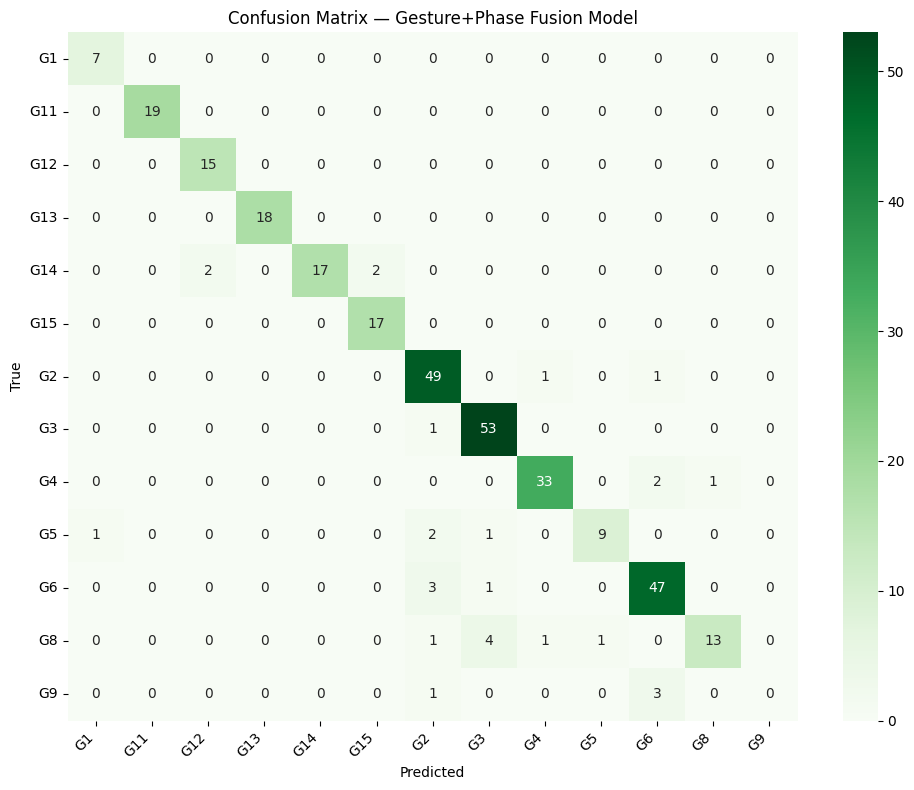

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# 1. Load best checkpoint and evaluate
fusion_model.load_state_dict(torch.load('/kaggle/working/best_fusion_head.pth'))
fusion_model.eval()

with torch.no_grad():
  test_out, final_w = fusion_model(test_g_t, test_p_t)
  final_preds = test_out.argmax(dim=1).cpu().numpy()

final_acc = accuracy_score(test_labels, final_preds)
final_f1 = f1_score(test_labels, final_preds, average='macro')
print(
    f'Best fusion checkpoint -> acc: {final_acc:.4f}, macro-F1: {final_f1:.4f}'
)
print(
    f'Learned weights -> gesture: {final_w[0].item():.3f}, phase:'
    f' {final_w[1].item():.3f}'
)

# 2. Dynamic class label mapping (handles any number of classes automatically)
idx_to_gesture = {v: k for k, v in GESTURE_TO_IDX.items()}
num_classes = len(idx_to_gesture)
label_names = [idx_to_gesture[i] for i in range(num_classes)]

# 3. Generate and save Classification Report
report = classification_report(
    test_labels,
    final_preds,
    target_names=label_names,
    output_dict=True,
    zero_division=0,
)
report_df = pd.DataFrame(report).transpose()
print('\n--- Classification Report ---')
print(report_df.round(3))
report_df.to_csv('/kaggle/working/fusion_classification_report.csv')

# 4. Plot and save Confusion Matrix
cm = confusion_matrix(test_labels, final_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_names,
    yticklabels=label_names,
    cmap='Greens',
)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Gesture+Phase Fusion Model')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/fusion_confusion_matrix.png', dpi=200)
plt.show()

In [19]:
comparison = pd.DataFrame({
    'Model': ['Gesture-only (C(2+1)D)', 'Gesture+Phase (Weighted Fusion)'],
    'Accuracy': [0.9018, final_acc],
    'Macro-F1': [0.8353, final_f1],
    'G9 F1': [0.000, report_df.loc['G9','f1-score']]
})
print(comparison)

                             Model  Accuracy  Macro-F1  G9 F1
0           Gesture-only (C(2+1)D)  0.901800  0.835300    0.0
1  Gesture+Phase (Weighted Fusion)  0.911043  0.841247    0.0
